In [1]:
# Install the package with my custom environment
import sys
!{sys.executable} -m pip install -e /home/a/A.Rivera/Code_Projects/1_Thesis_Code/TASEP_2D/SmartTASEP/gym-environments

Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///home/a/A.Rivera/Code_Projects/1_Thesis_Code/TASEP_2D/SmartTASEP/gym-environments
  Preparing metadata (setup.py) ... done
  Attempting uninstall: gym-environments
    Found existing installation: gym-environments 0.0.1
    Uninstalling gym-environments-0.0.1:
      Successfully uninstalled gym-environments-0.0.1
  Running setup.py develop for gym-environments


In [1]:
# ==================================================
# Program Description
# ==================================================

# This program will apply Deep Q-Network to a 2D multiparticle system in which each particle will move following a TASEP (totally asymmetric exclusion process).
# Each particle will have a fixed jumping rate for the forward jump and equal to 1/2 for the up and downwards directions.
# After the optimization, the system will choose the specific particle that will increase the horizontal current instead of going with random sequential updating.

In [1]:
import gymnasium as gym
import gym_environments # My own library with the 2D TASEP Lattice
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np
import math
import random
from numba import njit
from tqdm import tqdm

import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if GPU is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# ==================================================
# Replay Memory/Replay Buffer
# ==================================================
# This is the list where the transitions are saved and randomly sampled to use more efficiently the experiences

# structure of the Q table
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))  # Using a named tuple to be more readable, it creates a tuple named Transition with values (bla, blabla, blablabla)

# class that defines the Q table
class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity) #list-like container with fast appends and pops on either end. # deque is a more efficient form of a list

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory) # Return the number of items in a list


In [3]:
# ==================================================
# DQN algorithm
# ==================================================
#   To calculate the current Q-value, the input is the state and the action.
#   Q-value = expected return of taking each action given the current state.

class DQN(nn.Module):
    # Según como sea el tipo de dato del state, tendremos que pasarlo a torch.tensor y modificar el shape de éste de forma que su size sea ([1, algo])
        # Si es un vector, solo hay que añadir state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        # Si es un int, state = torch.tensor(state, dtype=torch.float32).view(1,1)
        # Si es una matriz, se reduce la dimensionalidad del input state = torch.tensor(np.reshape(state, (1,16)), dtype=torch.float32)


    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)  # torch.nn.functional.linear(input_dims, weight_dims, bias=None): y=x*W+b
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        
        return self.layer3(x)

# greedy epsilon policy implementation    
def select_action(state):
    global steps_done  #count total number of steps to go from almost random exploration to more efficient actions
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold: # Explotation: best known action
        with torch.no_grad():      
            # - t.max(1) will return the largest column value of each row.
            # second column on max result is index of where max element was
            # found, so we pick action with the larger expected reward.
            return policy_net(state).max(1)[1].view(1,1)   # view (1,1) makes a tensor of dim 1 with one element: tensor([[value]])
        
    else:  # Exploration: random action
        return torch.tensor([[env.action_space.sample() ]], device=device, dtype=torch.long)
        #Not sure this is correct


# random policy implementation (no learning)
def select_particle_random(n):
    return torch.tensor([[random.randint(0, n-1)]], device=device, dtype=torch.long) 

@njit
def autocorrelation(System, SystemSnapshot):
    Ly, Lx = System.shape
    Ly0,Lx0 = SystemSnapshot.shape
    
    if Ly0 != Ly or Lx0 != Lx:
        raise ValueError("Shape of System and SystemSnapshot is not equal")
    
    size = Lx * Ly    
    DensityParticles = np.sum(System) / size
    
    Sum = 0
    for i in range(Ly):
        for j in range(Lx):
            Sum += System[i][j] * SystemSnapshot[i][j]
    Corr = (Sum / size) - (DensityParticles)**2 # 0.25 is the density of particles^2
    
    return Corr

In [4]:
def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf() # clf -- clear current figure
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())
            
# def show_state(env, step = 0, info=""):
#     plt.figure(3)
#     plt.clf()
#     plt.imshow(env.render())
#     plt.title("%s | Step: %d %s" % ("frozen_lake", step, info))
#     plt.axis('off')

#     display.display(plt.gcf())

In [5]:
# Training loop

def optimize_model():
    if len(memory) < BATCH_SIZE: # execute 'optimize_model' only if #BATCH_SIZE number of updates have happened 
        return
    
# It samples a batch, concatenates all the tensors into a single one        
    transitions = memory.sample(BATCH_SIZE) 
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))
    
    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=device, dtype=torch.bool) # returns a set of booleans
                                                                                                                          #The map() function runs a lambda function over a list building a list-like collection of the results 
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None]) # creates a list of non-empty next states
    
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)
    
#-------------------------------------------------------------------------------------------------------------------------------------------------------    

    # Compute Q(s_t, a)
    #  The model computes Q(s_t), then we select the
    #  columns of actions taken. These are the actions which would've been taken
    #  for each batch state according to policy_net
    
    # Policy_net produces [[Q1,...,QN], ...,[]] (BATCH x N)-sized matrix, where N is the size of action space (4), 
    # and action_batch is BATCH-sized vector whose values are the actions that have been taken. 
    # Gather tells which Q from [Q1,...,QN] row to take, using action_batch vector, and returns BATCH-sized vector of Q(s_t, a) values
    state_values = policy_net(state_batch)
    state_action_values = state_values.gather(1, action_batch) # input = policy_net, dim = 1, index = action_batch
                                                               # torch.gather(input, dim, index). Gathers values along an axis specified by dim.
  
    # Compute the target network V(s_{t+1}) for all next states.
    #  Expected values of actions for non_final_next_states are computed based
    #  on the "older" target_net; selecting their best reward with max(1)[0].
    #  This is merged based on the mask, such that we'll have either the expected
    #  state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad(): # disable gradient calculation.
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0]
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()


In [6]:
#env = gym.make('gym_environments/Lattice-v0', render_mode="ansi", mode = "chess", Lx = 4, Ly = 2, n = 4, max_steps = 4, mu = 0.5, sigma = 0.3)
#print("observation_space:", env.observation_space) # MultiBinary, Lx*Ly grid with 0s and 1s representing the occupation of the lattice
#print("action_space:", env.action_space) # Discrete (3): up, down, left
#print("reward_range:", env.reward_range)
#print("metadata:", env.metadata)
#state = env.reset()
#state

In [7]:
def Simulate(runsNumber, totalMCS, Lx, Ly, n, mu, sigma):
    
    env = gym.make('gym_environments/Lattice-v0', render_mode="ansi", mode = "chess", Lx = Lx, Ly = Ly, n = n, max_steps = totalMCS*n, mu = mu, sigma = sigma)    
    print("observation_space:", env.observation_space) # MultiBinary, Lx*Ly grid with 0s and 1s representing the occupation of the lattice
    print("action_space:", env.action_space) # Discrete (3): up, down, left
    print("reward_range:", env.reward_range)
    print("metadata:", env.metadata)
 # Memory allocation                   
    DensityParticlesTot = np.zeros(totalMCS, dtype=np.float32) 
    CorrTot = np.zeros(totalMCS, dtype=np.float32) 
    CurrentAlongTot = np.zeros(totalMCS, dtype=np.float32)  # totalMCS vectors with Ly (zero) components 
    CurrentTransvTot = np.zeros(totalMCS, dtype=np.float32)  # totalMCS vectors with Ly (zero) components
    OccupationGridTot = np.zeros((Ly, Lx), dtype=np.float32)


    for iwalk in tqdm(range(runsNumber)):
        #print("Run number:", iwalk)
        # Initialize the environment and get its state
        state, info = env.reset()
        #print("Después de reset",state, info)        
        #init_observation = state
        state = torch.tensor(np.reshape(state, (1, Lx*Ly)), dtype=torch.float32, device=device)
        #SystemSnapshot = init_observation.copy()

       # Memory allocation                   
        Corr = np.zeros(totalMCS, dtype=np.float32)
        DensityParticles = np.zeros(totalMCS, dtype=np.float32) 
        OccupationGrid = np.zeros((Ly, Lx), dtype=np.float32)
        CurrentAlong = np.zeros(totalMCS, dtype=np.float32) 
        CurrentTransv = np.zeros(totalMCS, dtype=np.float32)        
            
        for istep in range(totalMCS): # totalMCS of N movements
            #print("Después de n movements", state, info)        
            Along_count = 0
            Transv_count = 0
            # Computes correlation function; CorrFunction[0] = 0.25 by definition 
            #Corr[istep] += autocorrelation(init_observation[0], SystemSnapshot)
            
            for moveAttempt in range(n):
                #print("moveAttemp:", moveAttempt)                
                #Agent-Enviroment Loop = Agent interacts with the enviroment
                #action = select_particle_random(n) #No learning
                #print("before", state)
                
                # greedy epsilon policy implementation    
                action = select_action(state)
                #print(action)

                
                observation, reward, terminated, truncated, info = env.step(action.item())
                reward = torch.tensor([reward], device=device)
                done = terminated or truncated # It always does totalMCS*n movements per episode
                #print(observation)
                
                Along_count += info["Along_Steps"]
                Transv_count += info["Transv_Steps"]
                #print("moveAttemp:", moveAttempt, observation, Along_count)

                if done:
                    next_state = None
                else:
                    next_state = torch.tensor(np.reshape(observation, (1, Lx*Ly)), dtype=torch.float32, device=device)

                # Store the transition in memory
                memory.push(state, action, next_state, reward)

                # Move to the next state
                state = next_state
                
                
                # Perform one step of the optimization (on the policy network)
                optimize_model()

                    
            #-------------------------------------------------------------------------------------------------------------------------------------------------------    

                
                # Soft update of the target network's weights
                # θ′ ← τ θ + (1 −τ )θ′
                target_net_state_dict = target_net.state_dict()
                policy_net_state_dict = policy_net.state_dict()
                for key in policy_net_state_dict:
                    target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
                target_net.load_state_dict(target_net_state_dict)
                
                    
            # Computes currents
            CurrentAlong[istep] = Along_count/n # Sum of the current along Lx
            CurrentTransv[istep] = Transv_count/n # Sum of the current along Ly            

            # Computes the total number of particles
            DensityParticles[istep] = np.sum(observation) / size
            # Frames for the movie at the last MCS
            #JumpRate_short_movie[istep+1] = JumpRateGrid            

            # To compute occupation probability
            OccupationGrid += observation         
            
            
        #plot_durations(show_result=True)

        # Computing parameters after a single run
        OccupationGrid /= totalMCS
        OccupationGridTot += OccupationGrid
        
        for dt in range(totalMCS):
            CorrTot[dt] += Corr[dt]
            DensityParticlesTot[dt] += DensityParticles[dt] 
            CurrentAlongTot[dt] += CurrentAlong[dt]
            CurrentTransvTot[dt] += CurrentTransv[dt]  
            
        #print('Runs done:', iwalk+1)            
        
    # Simulation results output
    for dt in range(totalMCS):
        CorrTot[dt] /= runsNumber
        DensityParticlesTot[dt] /= (runsNumber)
        CurrentAlongTot[dt] /= (runsNumber)
        CurrentTransvTot[dt] /= (runsNumber)

    # Occupation probability along the X axis
    OccupationGridTot /= runsNumber
    HorizontalOccupProb = OccupationGridTot.sum(axis=0)/Ly

    print('Complete')
    
    return DensityParticlesTot, CorrTot, CurrentAlongTot, CurrentTransvTot, HorizontalOccupProb

In [8]:
def density_particles(sigma):
    DensityParticlesTot, CorrTot, CurrentAlongTot, CurrentTransvTot, HorizontalOccupProb = Simulate(runsNumber, totalMCS, Lx, Ly, n, mu, sigma)    
    x_axis=np.array(range(totalMCS))
    plt.plot(x_axis[5:], DensityParticlesTot[5:], color='blue')
    
    plt.title(f"SmartTASEP. Gaussian jumping rate over {runsNumber} runs")
    plt.xlabel('Time')
    plt.ylabel('Density of Particles')

    plt.grid(True) 
    #plt.savefig('Random_sigma=0,3 - Density.pdf')
    
def autocorrelation_plot(sigma):
    DensityParticlesTot, CorrTot, CurrentAlongTot, CurrentTransvTot, HorizontalOccupProb = Simulate(runsNumber, totalMCS, Lx, Ly, n, mu, sigma)    
    x_axis=np.array(range(1,totalMCS+1))
    f=1/x_axis
    f2 = 0.1*x_axis**(-1.1)
    plt.plot(x_axis[5:], f2[5:], color='black', label = 'Out of the steady state')
    plt.plot(x_axis[5:], CorrTot[5:], '.', color='coral', label = 'Samples')
    plt.title(f"SmartTASEP. Gaussian jumping rate over {runsNumber} runs")
    plt.xlabel('Time (log scale)')
    plt.ylabel('Autocorrelation Function (log scale)')
    plt.legend()

    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True)

    #plt.savefig('Random_sigma=0,01 - Autocorrelation')
    
def occup_prob(sigma):
    x_axis=np.array(range(Lx))
    DensityParticlesTot, CorrTot, CurrentAlongTot, CurrentTransvTot, HorizontalOccupProb = Simulate(runsNumber, totalMCS, Lx, Ly, n, mu, sigma)    

    plt.plot(x_axis, HorizontalOccupProb, '.')
    
    plt.title(f"SmartTASEP. Gaussian jumping rate over {runsNumber} runs")
    plt.xlabel('Horizontal length')
    plt.ylabel('Occupation probability')
    plt.ylim([0.4,0.6])
    plt.grid(True)

    #plt.savefig('Random_sigma=0,01 - Occupation probability.pdf')
    
def current_plot(sigma):
    plt.cla()
    x_axis=np.array(range(totalMCS))
    DensityParticlesTot, CorrTot, CurrentAlongTot, CurrentTransvTot, HorizontalOccupProb = Simulate(runsNumber, totalMCS, Lx, Ly, n, mu, sigma)    
    #The steady current of particle J, through a bond i, i+1 is given by the rate r multiplied by the probability that there is a particle at site i, and site i+1 is vacant
    r = 0.5 #jumping rate
    p = 0.5 #probability forward
    prob_occ=1 # we make a transition only when the site chosen is occupied
    prob_vac=1/2 #density of particles in the system

    f=np.array([r*p*prob_occ*prob_vac]*totalMCS)
    sigma = fixed_sigma
    plt.plot(x_axis[5:], CurrentAlongTot[5:], '.', label='Parallel Current')
    plt.plot(x_axis[5:], CurrentTransvTot[5:], '.', label='Perpendicular Current')

    plt.plot(x_axis,f, label='Parallel Current for p=1/2', color = 'red')
    
    plt.title(f"SmartTASEP. Gaussian jumping rate over {runsNumber} runs")
    plt.xlabel('Time')
    plt.ylabel(f'Current. {n} moves averaged')
    plt.legend(loc = 'center left')


    plt.grid(True)

    #plt.savefig('Random_sigma=0,01 -  Currents.pdf')
    

In [9]:
# Current comparison
def currents_sigmas():
   # Plot
    plt.cla()
    plt.title(f"SmartTASEP. Gaussian jumping rate over {runsNumber} runs")
    plt.xlabel('Time')
    plt.ylabel('Current')
    plt.grid(True)

    plt.rcParams['text.usetex'] = True
    
    #for sigma in [0.0001, 0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 5.0]:
    for sigma in tqdm([0.0001, 0.1, 0.6, 5.0]):   
        DensityParticlesTot, CorrTot, CurrentAlongTot, CurrentTransvTot, HorizontalOccupProb = Simulate(runsNumber, totalMCS, Lx, Ly, n, mu, sigma)    
        times = np.array(range(totalMCS))     
        plt.plot(times, CurrentAlongTot, label=f"$\\sigma = {sigma}$")
        
    plt.legend()
    plt.savefig('Pictures/Current_Different_Sigmas/Currents.pdf')
    
    
def average_run_current(sigmas):
    currents = np.zeros(sigmas.shape[0], dtype = np.float32)    
    i = 0
    for sigma in tqdm(sigmas):
        DensityParticlesTot, CorrTot, CurrentAlongTot, CurrentTransvTot, HorizontalOccupProb = Simulate(runsNumber, totalMCS, Lx, Ly, n, mu, sigma)    
        currents[i] = np.mean(CurrentAlongTot)
        i += 1
        #print(i)
    return currents

def average_run_current_over_sigmas():
   # Plot
    plt.cla()
    plt.xlabel('Standard Deviation, $\\sigma$ (log scale)')
    plt.xscale('log')
    plt.ylabel('Current')
    plt.title(f"SmartTASEP. Gaussian jumping rate over {runsNumber} runs")
    plt.grid(True)

    plt.rcParams['text.usetex'] = True        
    
    sigmas = np.logspace(-4, 1, 15, dtype=np.float32)        
    currents = average_run_current(sigmas)
    plt.plot(sigmas, currents)
    plt.savefig('Pictures/Current_Different_Sigmas/AverageCurrentVsSigma.pdf')        

In [12]:
# our main
if __name__ == '__main__':
    
    # Simulation parameters
    Lx = 20 # Number of columns, length
    Ly = 10 # Number of rows, height
    n = Lx * Ly // 2
    size = Lx * Ly
    mu = 0.5
    fixed_sigma = 0.001
    
    runsNumber = 3
    if torch.cuda.is_available():
        totalMCS = 600
    else:
        totalMCS = 100
        
    
    env = gym.make('gym_environments/Lattice-v0', render_mode="ansi", mode = "chess", Lx = Lx, Ly = Ly, n = n, max_steps = totalMCS*n, mu = mu, sigma = fixed_sigma)    
    
 
        
    # Hyperparameters of the DQN
    BATCH_SIZE = 128   # BATCH_SIZE is the number of transitions sampled from the replay buffer
    GAMMA = 0.95       # GAMMA is the discount factor as mentioned in the previous section
    EPS_START = 0.9    # EPS_START is the starting value of epsilon
    EPS_END = 0.05     # EPS_END is the final value of epsilon
    EPS_DECAY = 1000   # EPS_DECAY controls the rate of exponential decay of epsilon, higher means a slower decay

    TAU = 0.005        # TAU is the update rate of the target network
    LR = 1e-4          # LR is the learning rate of the ``AdamW`` optimizer


    # Get number of actions from gym action space: The number of particles in the system
    n_actions = env.action_space.n
    
    # Get the number of state observations: The size of the lattice Lx*Ly (int from 0 to Lx*Ly or an array with zeros and ones [Ly,Lx])
    state, info = env.reset()
    initial_state = state.copy()
    n_observations = np.size(initial_state)

    policy_net = DQN(n_observations, n_actions).to(device)  # We create an instance of DQN, and move it to the device
    target_net = DQN(n_observations, n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict()) # Using fixed parameters from the policy network. 
                                                        # state_dict(): Python dictionary object that maps each layer to its parameter tensor (W,B)
#    for param_tensor in policy_net.state_dict():
#        print(param_tensor, "\t", policy_net.state_dict()[param_tensor].size())

    optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
    memory = ReplayMemory(10000)

    steps_done = 0
    episode_durations = []
       
        
    plt.rcParams["figure.figsize"] = (8, 4)
    plt.rcParams["figure.dpi"] = 80
    plt.rcParams["font.size"] = 11

   # Fixed sigma plots
    #density_particles(fixed_sigma)
    #autocorrelation_plot(fixed_sigma)
    #occup_prob(fixed_sigma)
    #current_plot(fixed_sigma)
    
   # Different sigmas plots
    #currents_sigmas()
    #average_run_current_over_sigmas()
    
    DensityParticlesTot, CorrTot, CurrentAlongTot, CurrentTransvTot, HorizontalOccupProb = Simulate(runsNumber, totalMCS, Lx, Ly, n, mu, fixed_sigma)    


observation_space: MultiBinary((10, 20))
action_space: Discrete(100)
reward_range: (-inf, inf)
metadata: {'render_modes': ['ansi', 'rgb_array'], 'render_fps': 4}


100%|██████████| 3/3 [02:30<00:00, 50.22s/it]

Complete


In [13]:
CurrentAlongTot

array([0.07333334, 0.05      , 0.05666667, 0.06333333, 0.04333333,
       0.04333333, 0.03666667, 0.03666667, 0.05333334, 0.03333334,
       0.06      , 0.04666667, 0.03333334, 0.04666667, 0.02333333,
       0.02666667, 0.04333333, 0.04      , 0.03      , 0.05      ,
       0.03      , 0.03      , 0.03      , 0.03666667, 0.03      ,
       0.05666667, 0.03      , 0.02666667, 0.04666667, 0.02666667,
       0.01      , 0.02333333, 0.03333334, 0.04333334, 0.02666667,
       0.02      , 0.04      , 0.02      , 0.04333333, 0.03666667,
       0.02      , 0.03333333, 0.03333334, 0.01      , 0.01333333,
       0.02666667, 0.05666667, 0.02666667, 0.01666667, 0.02333333,
       0.01666667, 0.00333333, 0.02333333, 0.03333334, 0.01666667,
       0.02333333, 0.03333333, 0.00666667, 0.01333333, 0.03      ,
       0.03333334, 0.02      , 0.03666667, 0.03333334, 0.02      ,
       0.04      , 0.04      , 0.04666667, 0.04      , 0.05      ,
       0.03      , 0.03      , 0.05333333, 0.02      , 0.06   

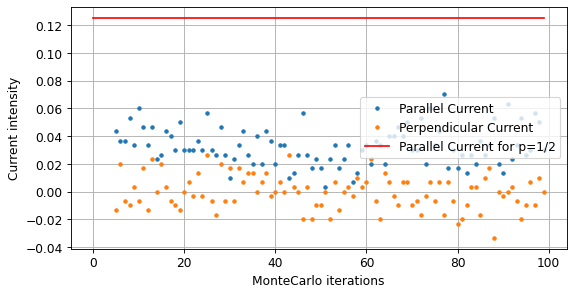

In [14]:
x_axis=np.array(range(totalMCS))

#The steady current of particle J, through a bond i, i+1 is given by the rate r multiplied by the probability that there is a particle at site i, and site i+1 is vacant
r = 0.5 #jumping rate
p = 0.5 #probability forward
prob_occ=1 # we make a transition only when the site chosen is occupied
prob_vac=1/2 #density of particles in the system

f=np.array([r*p*prob_occ*prob_vac]*totalMCS)
sigma = fixed_sigma
plt.plot(x_axis[5:], CurrentAlongTot[5:], '.', label='Parallel Current')
plt.plot(x_axis[5:], CurrentTransvTot[5:], '.', label='Perpendicular Current')

plt.plot(x_axis,f, label='Parallel Current for p=1/2', color = 'red')

plt.xlabel('MonteCarlo iterations')
plt.ylabel('Current intensity')
plt.legend(loc = 'center right')


plt.grid(True)

#plt.savefig('Random_sigma=0,01 -  Currents.pdf')

plt.show()

In [62]:
# Simulation parameters
Lx = 4 # Number of columns, length
Ly = 2 # Number of rows, height
n = Lx * Ly // 2
size = Lx * Ly
mu = 0.5
fixed_sigma = 0.3

runsNumber = 2
if torch.cuda.is_available():
    totalMCS = 600
else:
    totalMCS = 15
steps_done = 0

# Hyperparameters of the DQN
BATCH_SIZE = 1   # BATCH_SIZE is the number of transitions sampled from the replay buffer
GAMMA = 0.95       # GAMMA is the discount factor as mentioned in the previous section
EPS_START = 0.9    # EPS_START is the starting value of epsilon
EPS_END = 0.05     # EPS_END is the final value of epsilon
EPS_DECAY = 1000   # EPS_DECAY controls the rate of exponential decay of epsilon, higher means a slower decay

TAU = 0.005        # TAU is the update rate of the target network
LR = 1e-4          # LR is the learning rate of the ``AdamW`` optimizer

env = gym.make('gym_environments/Lattice-v0', render_mode="ansi", mode = "chess", Lx = Lx, Ly = Ly, n = n, max_steps = totalMCS*n, mu = mu, sigma = fixed_sigma) 
#print("observation_space:", env.observation_space) # MultiBinary, Lx*Ly grid with 0s and 1s representing the occupation of the lattice
#print("action_space:", env.action_space) # Discrete (3): up, down, left
#print("reward_range:", env.reward_range)
#print("metadata:", env.metadata)
state, info = env.reset()
#state
state = torch.tensor(np.reshape(state, (1, Lx*Ly)), dtype=torch.float32, device=device)

action = select_action(state)


observation, reward, terminated, truncated, info = env.step(action.item())
reward = torch.tensor([reward], device=device)
done = terminated or truncated # It always does totalMCS*n movements per episode
#print(done)

#print("moveAttemp:", moveAttempt, observation, Along_count)

if done:
    next_state = None
else:
    next_state = torch.tensor(np.reshape(observation, (1, Lx*Ly)), dtype=torch.float32, device=device)

# Store the transition in memory
memory.push(state, action, next_state, reward)

In [96]:
if len(memory) < BATCH_SIZE:
    print("a")

a
